In [8]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ahemateja19bec1025/traffic-sign-dataset-classification/labels.csv
/kaggle/input/datasets/ahemateja19bec1025/traffic-sign-dataset-classification/traffic_Data/DATA/7/007_1_0060.png
/kaggle/input/datasets/ahemateja19bec1025/traffic-sign-dataset-classification/traffic_Data/DATA/7/007_1_0073.png
/kaggle/input/datasets/ahemateja19bec1025/traffic-sign-dataset-classification/traffic_Data/DATA/7/007_1_0045.png
/kaggle/input/datasets/ahemateja19bec1025/traffic-sign-dataset-classification/traffic_Data/DATA/7/007_1_0020.png
/kaggle/input/datasets/ahemateja19bec1025/traffic-sign-dataset-classification/traffic_Data/DATA/7/007_0012.png
/kaggle/input/datasets/ahemateja19bec1025/traffic-sign-dataset-classification/traffic_Data/DATA/7/007_0061.png
/kaggle/input/datasets/ahemateja19bec1025/traffic-sign-dataset-classification/traffic_Data/DATA/7/007_1_0074.png
/kaggle/input/datasets/ahemateja19bec1025/traffic-sign-dataset-classification/traffic_Data/DATA/7/007_1_0034.png
/kaggle/inp

In [9]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/ahemateja19bec1025
/kaggle/input/datasets/ahemateja19bec1025/traffic-sign-dataset-classification
/kaggle/input/datasets/ahemateja19bec1025/traffic-sign-dataset-classification/traffic_Data
/kaggle/input/datasets/ahemateja19bec1025/traffic-sign-dataset-classification/traffic_Data/DATA
/kaggle/input/datasets/ahemateja19bec1025/traffic-sign-dataset-classification/traffic_Data/DATA/7
/kaggle/input/datasets/ahemateja19bec1025/traffic-sign-dataset-classification/traffic_Data/DATA/47
/kaggle/input/datasets/ahemateja19bec1025/traffic-sign-dataset-classification/traffic_Data/DATA/17
/kaggle/input/datasets/ahemateja19bec1025/traffic-sign-dataset-classification/traffic_Data/DATA/19
/kaggle/input/datasets/ahemateja19bec1025/traffic-sign-dataset-classification/traffic_Data/DATA/22
/kaggle/input/datasets/ahemateja19bec1025/traffic-sign-dataset-classification/traffic_Data/DATA/2
/kaggle/input/datasets/ahemateja19bec1025/traffic-sign-dataset-c

In [10]:
DATASET_PATH = "/kaggle/input/datasets/ahemateja19bec1025/traffic-sign-dataset-classification/traffic_Data/DATA"

In [11]:
import tensorflow as tf

train_ds = tf.keras.utils.image_dataset_from_directory(
    "/kaggle/input/datasets/ahemateja19bec1025/traffic-sign-dataset-classification/traffic_Data/DATA",
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(64,64),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "/kaggle/input/datasets/ahemateja19bec1025/traffic-sign-dataset-classification/traffic_Data/DATA",
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(64,64),
    batch_size=32
)

print("Classes:", len(train_ds.class_names))

Found 4170 files belonging to 58 classes.
Using 3336 files for training.
Found 4170 files belonging to 58 classes.
Using 834 files for validation.
Classes: 58


In [28]:
import tensorflow as tf

train_ds = tf.keras.utils.image_dataset_from_directory(
    "/kaggle/input/datasets/ahemateja19bec1025/traffic-sign-dataset-classification/traffic_Data/DATA",
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(64,64),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "/kaggle/input/datasets/ahemateja19bec1025/traffic-sign-dataset-classification/traffic_Data/DATA",
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(64,64),
    batch_size=32
)

Found 4170 files belonging to 58 classes.
Using 3336 files for training.
Found 4170 files belonging to 58 classes.
Using 834 files for validation.


In [29]:
for images, labels in train_ds.take(1):
    print(images[0].numpy().min())
    print(images[0].numpy().max())
    break

15.099976
124.70422


In [33]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(64,64,3)),
    MaxPooling2D(),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(),

    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(),

    Flatten(),

    Dense(128,activation='relu'),

    Dropout(0.5),

    Dense(58,activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [34]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 58)             │         7,482 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 690,682 (2.63 MB)

 Trainable params: 690,682 (2.63 MB)

 Non-trainable params: 0 (0.00 B)

In [36]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully")

Model compiled successfully


In [37]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
105/105 ━━━━━━━━━━━━━━━━━━━━ 16s 133ms/step - accuracy: 0.0800 - loss: 4.6901 - val_accuracy: 0.0827 - val_loss: 3.5638
Epoch 2/5
105/105 ━━━━━━━━━━━━━━━━━━━━ 13s 125ms/step - accuracy: 0.0962 - loss: 3.6870 - val_accuracy: 0.0983 - val_loss: 3.3935
Epoch 3/5
105/105 ━━━━━━━━━━━━━━━━━━━━ 20s 123ms/step - accuracy: 0.1124 - loss: 3.6212 - val_accuracy: 0.1679 - val_loss: 3.4132
Epoch 4/5
105/105 ━━━━━━━━━━━━━━━━━━━━ 13s 126ms/step - accuracy: 0.1016 - loss: 3.6067 - val_accuracy: 0.1667 - val_loss: 3.3230
Epoch 5/5
105/105 ━━━━━━━━━━━━━━━━━━━━ 13s 125ms/step - accuracy: 0.1058 - loss: 3.5534 - val_accuracy: 0.1571 - val_loss: 3.2835


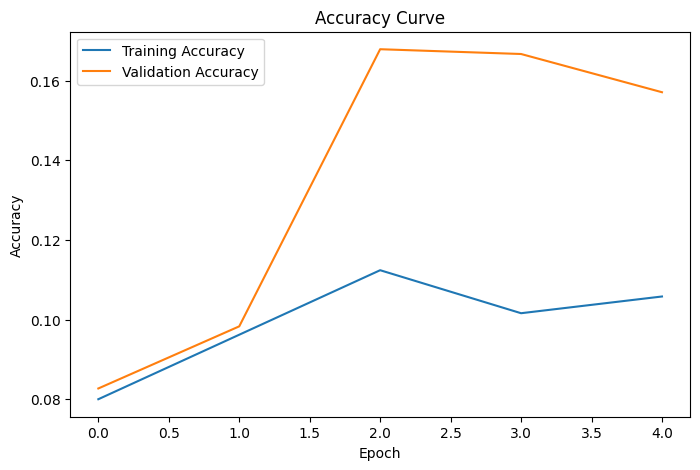

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

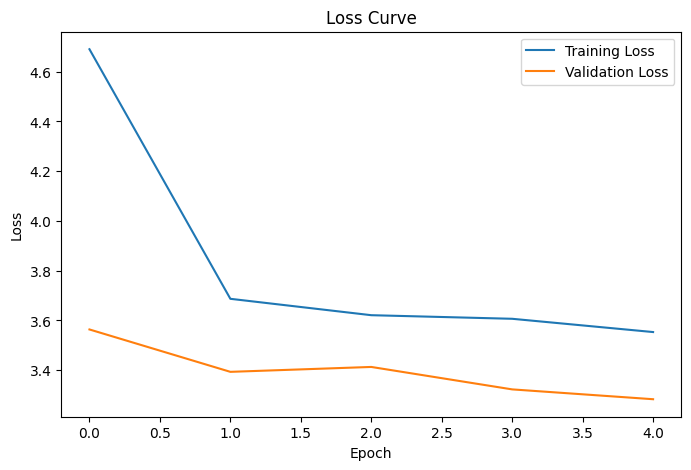

In [42]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [43]:
from sklearn.metrics import classification_report
import numpy as np

y_true = np.concatenate([y for x, y in val_ds], axis=0)

y_pred = np.argmax(model.predict(val_ds), axis=1)

print(classification_report(y_true, y_pred))

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        25
           1       0.00      0.00      0.00         4
           2       0.00      0.00      0.00        11
           3       0.00      0.00      0.00        31
           4       0.00      0.00      0.00        22
           5       0.00      0.00      0.00         7
           6       0.00      0.00      0.00        25
           7       0.00      0.00      0.00         4
           8       0.00      0.00      0.00        27
           9       0.00      0.00      0.00        32
          10       0.00      0.00      0.00         3
          11       0.00      0.00      0.00         1
          12       0.00      0.00      0.00         9
          13       0.00      0.00      0.00         1
          14       0.00      0.00      0.00         2
          15       0.00      0.00      0.00         1
          16       0.00      0.00      0.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


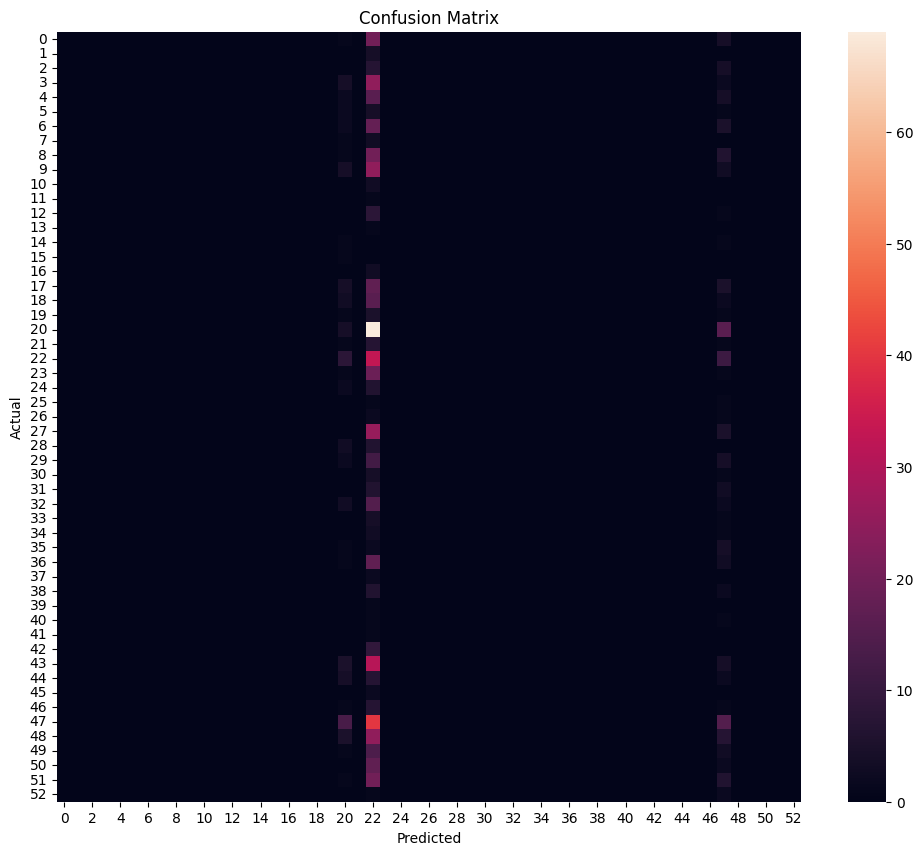

In [44]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12,10))
sns.heatmap(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [47]:
model.save("traffic_sign_model.keras")